# MultiCycPermea — Per-setting hard sample deep dive

For each split (ID / OD / Cliff_ratio; OD_Murcko added if its dump is present), this notebook produces:

1. **Top-K hardest molecules** with SMILES, structure image, full descriptor row.
2. **Hardness driver** — fit a `GradientBoostingRegressor` to (descriptors → |residual|) and report the top features (permutation importance).
3. **2D hard regions** — descriptor pair scatter with hard samples highlighted.
4. **Sequence-level** — monomer-length distribution of hard vs rest.
5. **Cross-split overlap** — how many hard samples are shared across splits.
6. **Per-setting written summary** at the end.

In [1]:
from pathlib import Path
import math, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, spearmanr
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from rdkit import Chem
from rdkit.Chem import Draw, AllChem, DataStructs
from IPython.display import display

ROOT  = Path('/ssd0/sohyun/cyclic_peptide/cyclic_peptide_permeability')
MCP   = ROOT / 'MultiCycPermea' / 'DL'
PRED  = MCP / 'pred_data'
DATA  = MCP / 'data' / 'ours'

DESC_COLS = [
    'Sequence_LogP','Sequence_TPSA','Monomer_Length','Monomer_Length_in_Main_Chain',
    'MolWt','HeavyAtomMolWt','ExactMolWt','NumValenceElectrons',
    'qed','MaxPartialCharge','MinPartialCharge',
    'FpDensityMorgan1','FpDensityMorgan2','FpDensityMorgan3',
    'NumHDonors','NumHAcceptors','NumRotatableBonds','NumAromaticRings','RingCount',
    'TPSA','MolLogP','LabuteASA','EPSA','PSA','_3DPSA',
]

def latest(prefix):
    hits = sorted(PRED.glob(f'{prefix}*/best_test_predictions.csv'))
    return hits[-1] if hits else None

DUMPS = {}
for s, prefix in [
    ('ID','ours_ID_dump_'),
    ('OD','ours_OD_dump_'),
    ('Cliff_ratio','ours_Cliff_ratio_dump_'),
    ('OD_Murcko','ours_OD_Murcko_dump_'),
]:
    p = latest(prefix)
    if p is not None:
        DUMPS[s] = p
print('found dumps:'); [print(f'  {k}: {v.relative_to(ROOT)}') for k, v in DUMPS.items()]

found dumps:
  ID: MultiCycPermea/DL/pred_data/ours_ID_dump_20260527_110940/best_test_predictions.csv
  OD: MultiCycPermea/DL/pred_data/ours_OD_dump_20260527_110940/best_test_predictions.csv
  Cliff_ratio: MultiCycPermea/DL/pred_data/ours_Cliff_ratio_dump_20260527_111201/best_test_predictions.csv


[None, None, None]

In [2]:
def load_split(split, pred_path):
    pred = pd.read_csv(pred_path)
    test = pd.read_csv(DATA / f'{split}_test.csv')
    keep = ['CycPeptMPDB_ID','PAMPA','SMILES','Sequence'] + [c for c in DESC_COLS if c in test.columns]
    df = pred.merge(test[keep], on='CycPeptMPDB_ID', how='left')
    df['residual'] = df['y_pred'] - df['y_true']
    df['abs_residual'] = df['residual'].abs()
    df['split'] = split
    return df

frames = {s: load_split(s, p) for s, p in DUMPS.items()}
summary_rows = []
for s, df in frames.items():
    summary_rows.append({
        'split': s, 'N': len(df),
        'MAE': df['abs_residual'].mean(),
        'RMSE': (df['residual']**2).mean()**0.5,
        'bias': df['residual'].mean(),
        'p90_|res|': df['abs_residual'].quantile(0.9),
    })
summary = pd.DataFrame(summary_rows).round(4)
summary

,split,N,MAE,RMSE,bias,p90_|res|
0,ID,491,0.2735,0.4155,-0.0379,0.5514
1,OD,488,0.3774,0.5476,0.1930,0.8504
2,Cliff_ratio,493,0.2840,0.4388,-0.0178,0.6097


## 1. Top-20 hardest molecules per split (SMILES + structures)

In [3]:
def show_hardest(df, k=20):
    cols = ['CycPeptMPDB_ID','y_true','y_pred','residual','abs_residual',
            'MolLogP','TPSA','NumHDonors','NumHAcceptors','MolWt','Monomer_Length','qed','SMILES']
    cols = [c for c in cols if c in df.columns]
    return df.nlargest(k, 'abs_residual')[cols]

hardest_per_split = {s: show_hardest(df, k=20) for s, df in frames.items()}
for s, h in hardest_per_split.items():
    print(f'\n=== {s}: top-20 hardest ===')
    display(h.style.format({'y_true':'{:.3f}','y_pred':'{:.3f}','residual':'{:+.3f}','abs_residual':'{:.3f}',
                            'MolLogP':'{:.2f}','TPSA':'{:.1f}','MolWt':'{:.1f}','qed':'{:.3f}'}))


=== ID: top-20 hardest ===


,CycPeptMPDB_ID,y_true,y_pred,residual,abs_residual,MolLogP,TPSA,NumHDonors,NumHAcceptors,MolWt,Monomer_Length,qed,SMILES
273,6036,-9.000,-4.956,+4.044,4.044,2.95,235.5,3,11,1030.4,10,0.214,CC(=O)N1CCC[C@H]1C(=O)N(C)[C@H](CC(C)C)C(=O)N[C@@H]1C(=O)N(C)[C@H](CC(C)C)C(=O)N(C)[C@H](CC(C)C)C(=O)N(C)[C@H](CC(C)C)C(=O)N[C@@H](C)C(=O)N[C@H](CC(C)C)C(=O)N2CCC[C@H]2C(=O)O[C@@H]1C
10,4631,-4.000,-6.769,-2.769,2.769,2.15,177.3,4,7,766.0,7,0.314,CC(C)C[C@@H]1NC(=O)[C@H](C)N(C)C(=O)[C@@H]2CCCN2C(=O)[C@H](Cc2ccccc2)NC(=O)[C@@H](CC(C)C)NC(=O)[C@@H]2CCCN2C(=O)[C@H](CC(C)C)NC1=O
201,1820,-8.270,-5.872,+2.398,2.398,4.09,166.7,3,8,815.0,6,0.305,CCCC[C@@H]1NC(=O)[C@@H](CC(C)C)NC(=O)CN(CC2CCCCC2)C(=O)[C@@H](Cc2ccccc2)NC(=O)CN(Cc2ccc3c(c2)OCO3)C(=O)[C@H]2CCCN2C1=O
487,1729,-8.260,-6.758,+1.502,1.502,4.04,157.9,2,8,803.0,6,0.288,CCCCCN1CC(=O)N(C)[C@H](CC(C)C)C(=O)N[C@@H](CCCC)C(=O)N2CCC[C@@H]2C(=O)N(Cc2ccc3c(c2)OCO3)CC(=O)N[C@@H](Cc2ccccc2)C1=O
476,2363,-6.340,-4.948,+1.392,1.392,3.72,139.4,2,6,727.0,6,0.377,CC(C)C[C@@H]1NC(=O)[C@H](CC(C)C)N(C)C(=O)[C@@H](CC(C)C)N(C)C(=O)[C@H](CC(C)C)NC(=O)[C@H](Cc2ccccc2)N(C)C(=O)[C@@H](C)N(C)C1=O
22,6770,-7.550,-6.351,+1.199,1.199,2.26,253.0,5,11,1002.3,10,0.177,CC(=O)N1CCC[C@H]1C(=O)N[C@@H]1C(=O)N(C)[C@H](CC(C)C)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CC(C)C)C(=O)N(C)[C@H](C)C(=O)N[C@@H](CC(C)C)C(=O)N2CCC[C@@H]2C(=O)O[C@@H]1C
364,2958,-6.490,-5.437,+1.053,1.053,2.50,148.2,3,6,682.9,6,0.384,CC(C)C[C@H]1C(=O)N2CCC[C@H]2C(=O)N(C)[C@H](CC(C)C)C(=O)N[C@@H](Cc2ccccc2)C(=O)N[C@H](C)C(=O)N[C@H](CC(C)C)C(=O)N1C
174,3325,-5.080,-6.100,-1.020,1.020,2.16,157.0,4,6,668.9,6,0.333,CC(C)C[C@@H]1NC(=O)[C@@H]2CCCN2C(=O)[C@@H](CC(C)C)NC(=O)[C@H](CC(C)C)NC(=O)[C@@H](C)N(C)C(=O)[C@H](Cc2ccccc2)NC1=O
480,6818,-6.920,-5.936,+0.984,0.984,2.60,244.2,4,11,1016.3,10,0.207,CC(=O)N1CCC[C@H]1C(=O)N[C@@H]1C(=O)N(C)[C@H](CC(C)C)C(=O)N[C@H](CC(C)C)C(=O)N(C)[C@H](CC(C)C)C(=O)N(C)[C@H](CC(C)C)C(=O)N[C@@H](C)C(=O)N[C@@H](CC(C)C)C(=O)N2CCC[C@@H]2C(=O)O[C@@H]1C
428,5106,-4.890,-5.816,-0.926,0.926,3.23,159.8,2,7,808.1,7,0.368,CCCN1CC(=O)N(C)[C@H](CC(C)C)C(=O)N(C)[C@H](CC(C)C)C(=O)N2CCC[C@@H]2C(=O)N[C@H](CC(C)C)C(=O)N[C@@H](Cc2ccccc2)C(=O)N2CCC[C@@H]2C1=O



=== OD: top-20 hardest ===


,CycPeptMPDB_ID,y_true,y_pred,residual,abs_residual,MolLogP,TPSA,NumHDonors,NumHAcceptors,MolWt,Monomer_Length,qed,SMILES
325,1060,-7.000,-4.939,+2.061,2.061,3.57,159.7,3,7,755.0,6,0.330,CC(C)C[C@@H]1NC(=O)[C@@H](CC(C)C)N(C)C(=O)[C@@H](CC(C)C)N(C)C(=O)[C@H](Cc2ccc(O)cc2)NC(=O)[C@@H]2CCCN2C(=O)[C@@H](CC(C)C)N(C)C1=O
88,1106,-8.000,-5.946,+2.054,2.054,-0.78,217.7,7,9,710.8,6,0.183,CC(C)C[C@@H]1NC(=O)[C@H](Cc2ccccc2)NC(=O)[C@H]([C@@H](C)O)N(C)C(=O)CN(C)C(=O)[C@H]([C@@H](C)O)NC(=O)[C@H](Cc2ccc(O)cc2)NC1=O
143,1082,-8.000,-6.114,+1.886,1.886,0.30,186.0,6,7,648.8,6,0.260,CC(C)C[C@@H]1NC(=O)[C@@H](Cc2ccccc2)NC(=O)CNC(=O)[C@@H](C)NC(=O)[C@H](Cc2ccc(O)cc2)NC(=O)[C@@H]2CCCN2C1=O
175,1099,-8.000,-6.122,+1.878,1.878,0.06,194.8,7,7,636.8,6,0.223,CC[C@H](C)[C@@H]1NC(=O)[C@H](Cc2ccc(O)cc2)NC(=O)[C@H](Cc2ccccc2)NC(=O)CNC(=O)[C@H](C(C)C)NC(=O)CNC1=O
223,1078,-8.000,-6.125,+1.875,1.875,0.30,186.0,6,7,648.8,6,0.260,CC(C)C[C@@H]1NC(=O)[C@H](Cc2ccccc2)NC(=O)CNC(=O)[C@H](C)NC(=O)[C@H](Cc2ccc(O)cc2)NC(=O)[C@H]2CCCN2C1=O
399,1101,-8.000,-6.215,+1.785,1.785,-1.33,237.9,8,8,665.7,6,0.168,CC(C)C[C@@H]1NC(=O)CNC(=O)[C@H](Cc2ccccc2)NC(=O)[C@H](CC(N)=O)NC(=O)[C@H](Cc2ccc(O)cc2)NC(=O)[C@H](C)NC1=O
447,1094,-8.000,-6.215,+1.785,1.785,-2.29,157.0,4,6,454.5,6,0.323,C[C@@H]1NC(=O)[C@H](C)N(C)C(=O)[C@H](C)NC(=O)[C@H](C)N(C)C(=O)[C@H](C)NC(=O)[C@@H](C)NC1=O
318,1096,-8.000,-6.229,+1.771,1.771,0.79,177.2,5,7,674.8,6,0.301,CC(C)C[C@@H]1NC(=O)CNC(=O)[C@@H]2CCCN2C(=O)[C@H](Cc2ccc(O)cc2)NC(=O)[C@H](Cc2ccccc2)NC(=O)[C@@H]2CCCN2C1=O
162,4383,-7.790,-6.025,+1.765,1.765,3.73,159.8,2,7,882.1,7,0.273,C[C@@H]1C(=O)N(Cc2ccccc2)CC(=O)N[C@@H](Cc2ccccc2)CC(=O)N2CCC[C@@H]2C(=O)N(Cc2ccccc2)CC(=O)N[C@@H](Cc2ccccc2)C(=O)N2CCC[C@@H]2C(=O)N1C
455,2363,-6.340,-4.600,+1.740,1.740,3.72,139.4,2,6,727.0,6,0.377,CC(C)C[C@@H]1NC(=O)[C@H](CC(C)C)N(C)C(=O)[C@@H](CC(C)C)N(C)C(=O)[C@H](CC(C)C)NC(=O)[C@H](Cc2ccccc2)N(C)C(=O)[C@@H](C)N(C)C1=O



=== Cliff_ratio: top-20 hardest ===


,CycPeptMPDB_ID,y_true,y_pred,residual,abs_residual,MolLogP,TPSA,NumHDonors,NumHAcceptors,MolWt,Monomer_Length,qed,SMILES
259,6036,-9.000,-5.053,+3.947,3.947,2.95,235.5,3,11,1030.4,10,0.214,CC(=O)N1CCC[C@H]1C(=O)N(C)[C@H](CC(C)C)C(=O)N[C@@H]1C(=O)N(C)[C@H](CC(C)C)C(=O)N(C)[C@H](CC(C)C)C(=O)N(C)[C@H](CC(C)C)C(=O)N[C@@H](C)C(=O)N[C@H](CC(C)C)C(=O)N2CCC[C@H]2C(=O)O[C@@H]1C
66,6160,-9.000,-5.904,+3.096,3.096,2.60,244.2,4,11,1016.3,10,0.184,CC(=O)N1CCC[C@@H]1C(=O)N(C)[C@H](CC(C)C)C(=O)N[C@@H]1C(=O)N[C@H](CC(C)C)C(=O)N(C)[C@H](CC(C)C)C(=O)N(C)[C@@H](CC(C)C)C(=O)N[C@@H](C)C(=O)N[C@H](CC(C)C)C(=O)N2CCC[C@H]2C(=O)O[C@@H]1C
204,1820,-8.270,-5.549,+2.721,2.721,4.09,166.7,3,8,815.0,6,0.305,CCCC[C@@H]1NC(=O)[C@@H](CC(C)C)NC(=O)CN(CC2CCCCC2)C(=O)[C@@H](Cc2ccccc2)NC(=O)CN(Cc2ccc3c(c2)OCO3)C(=O)[C@H]2CCCN2C1=O
352,6165,-5.970,-7.295,-1.325,1.325,2.60,244.2,4,11,1016.3,10,0.184,CC(=O)N1CCC[C@@H]1C(=O)N(C)[C@H](CC(C)C)C(=O)N[C@@H]1C(=O)N(C)[C@@H](CC(C)C)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CC(C)C)C(=O)N(C)[C@@H](C)C(=O)N[C@H](CC(C)C)C(=O)N2CCC[C@H]2C(=O)O[C@@H]1C
38,4187,-5.300,-6.576,-1.276,1.276,2.49,168.5,3,7,780.0,7,0.365,CC(C)C[C@H]1NC(=O)[C@H](C)N(C)C(=O)[C@H]2CCCN2C(=O)[C@H](Cc2ccccc2)NC(=O)[C@@H](CC(C)C)N(C)C(=O)[C@H]2CCCN2C(=O)[C@@H](CC(C)C)NC1=O
205,5435,-5.290,-6.446,-1.156,1.156,2.15,177.3,4,7,766.0,7,0.314,CC(C)C[C@H]1NC(=O)[C@H](C)NC(=O)[C@@H]2CCCN2C(=O)[C@H](Cc2ccccc2)NC(=O)[C@@H](CC(C)C)N(C)C(=O)[C@@H]2CCCN2C(=O)[C@@H](CC(C)C)NC1=O
26,4485,-5.770,-6.871,-1.101,1.101,2.15,177.3,4,7,766.0,7,0.314,CC(C)C[C@H]1NC(=O)[C@@H](C)NC(=O)[C@@H]2CCCN2C(=O)[C@H](Cc2ccccc2)NC(=O)[C@@H](CC(C)C)N(C)C(=O)[C@@H]2CCCN2C(=O)[C@@H](CC(C)C)NC1=O
339,6194,-8.700,-7.622,+1.078,1.078,1.92,261.8,6,11,988.3,10,0.137,CC(=O)N1CCC[C@@H]1C(=O)N(C)[C@H](CC(C)C)C(=O)N[C@@H]1C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CC(C)C)C(=O)N[C@H](CC(C)C)C(=O)N[C@@H](C)C(=O)N[C@H](CC(C)C)C(=O)N2CCC[C@@H]2C(=O)O[C@@H]1C
426,3897,-5.830,-6.881,-1.051,1.051,2.15,177.3,4,7,766.0,7,0.314,CC(C)C[C@H]1NC(=O)[C@@H](C)NC(=O)[C@H]2CCCN2C(=O)[C@H](Cc2ccccc2)NC(=O)[C@@H](CC(C)C)N(C)C(=O)[C@H]2CCCN2C(=O)[C@@H](CC(C)C)NC1=O
335,3031,-5.240,-6.274,-1.034,1.034,1.82,165.8,5,6,654.9,6,0.287,CC(C)C[C@@H]1NC(=O)[C@H]2CCCN2C(=O)[C@H](CC(C)C)NC(=O)[C@@H](CC(C)C)NC(=O)[C@H](C)NC(=O)[C@H](Cc2ccccc2)NC1=O



=== ID — top-8 hardest ===


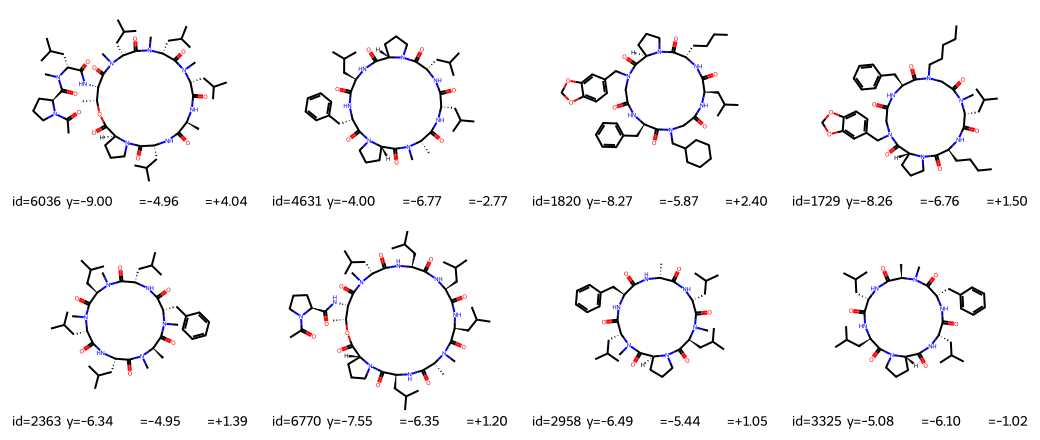


=== OD — top-8 hardest ===


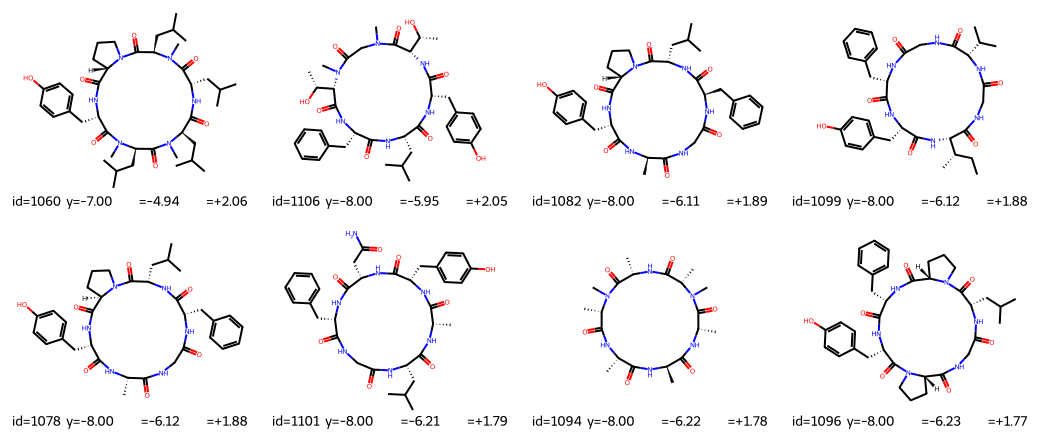


=== Cliff_ratio — top-8 hardest ===


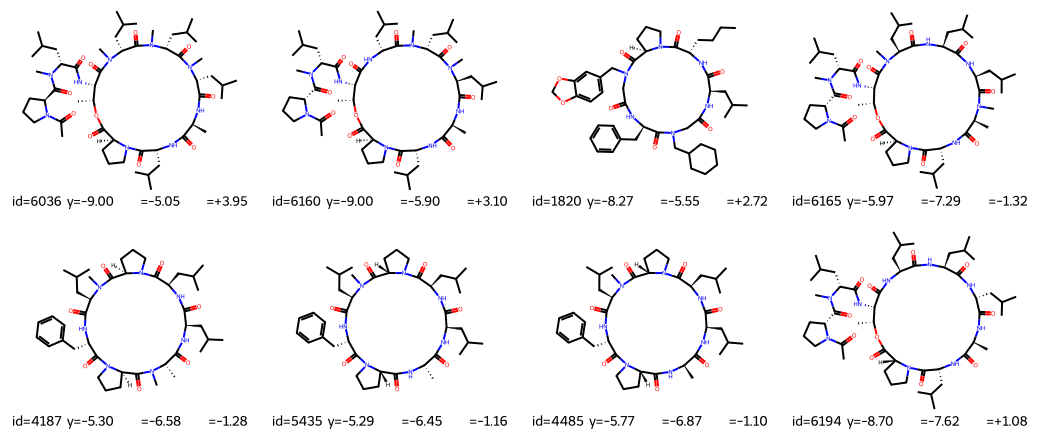

In [4]:
# 2D-structure grids for top-8 hardest per split
def draw_top(df, k=8, title=''):
    sub = df.nlargest(k, 'abs_residual').reset_index(drop=True)
    mols = [Chem.MolFromSmiles(s) for s in sub['SMILES']]
    valid = [(m, i) for i, m in enumerate(mols) if m is not None]
    mols_ok = [m for m, _ in valid]
    legends = [
        f"id={sub['CycPeptMPDB_ID'].iloc[i]} y={sub['y_true'].iloc[i]:.2f} \u0177={sub['y_pred'].iloc[i]:.2f} \u0394={sub['residual'].iloc[i]:+.2f}"
        for _, i in valid
    ]
    img = Draw.MolsToGridImage(mols_ok, molsPerRow=4, subImgSize=(260, 220), legends=legends)
    print(f'\n=== {title} ===')
    display(img)

for s, df in frames.items():
    draw_top(df, k=8, title=f'{s} — top-8 hardest')

## 2. Hardness driver via Gradient Boosting (permutation importance)

Fit GBR: descriptors → |residual|. Report the descriptors whose permutation most degrades the model — those are the strongest hardness predictors **within that split**.

In [5]:
def hardness_driver(df, n_features=15, random_state=0):
    feats = [c for c in DESC_COLS if c in df.columns]
    X = df[feats].apply(pd.to_numeric, errors='coerce')
    # drop columns that are all-NaN or mostly NaN (>50%)
    keep = X.columns[X.isna().mean() < 0.5].tolist()
    X = X[keep]
    # impute remaining NaN with median
    X = X.fillna(X.median(numeric_only=True))
    y = df['abs_residual'].values
    if X.shape[0] == 0 or X.shape[1] == 0:
        return None, float('nan'), pd.DataFrame(columns=['feature','perm_importance_mean','perm_importance_std'])
    gbr = GradientBoostingRegressor(max_depth=3, n_estimators=300, learning_rate=0.05, random_state=random_state)
    gbr.fit(X.values, y)
    score = gbr.score(X.values, y)
    perm = permutation_importance(gbr, X.values, y, n_repeats=10, random_state=random_state, n_jobs=4)
    order = np.argsort(perm.importances_mean)[::-1][:n_features]
    imp = pd.DataFrame({
        'feature': [keep[i] for i in order],
        'perm_importance_mean': perm.importances_mean[order],
        'perm_importance_std':  perm.importances_std[order],
    })
    return gbr, score, imp

driver_results = {}
for s, df in frames.items():
    gbr, r2, imp = hardness_driver(df)
    driver_results[s] = (gbr, r2, imp)
    print(f'\n=== {s}: GBR (descriptors -> |residual|) R^2_train={r2:.3f}; top features by permutation importance ===')
    display(imp.head(10).style.format({'perm_importance_mean':'{:.4f}','perm_importance_std':'{:.4f}'}))


=== ID: GBR (descriptors -> |residual|) R^2_train=0.401; top features by permutation importance ===


,feature,perm_importance_mean,perm_importance_std
0,FpDensityMorgan3,1.2912,0.0862
1,FpDensityMorgan1,0.2952,0.0161
2,FpDensityMorgan2,0.2804,0.0154
3,MolLogP,0.0563,0.0106
4,Monomer_Length_in_Main_Chain,0.0519,0.0059
5,MaxPartialCharge,0.0507,0.0048
6,MinPartialCharge,0.0416,0.0077
7,LabuteASA,0.0217,0.0106
8,qed,0.0209,0.0040
9,NumRotatableBonds,0.0086,0.0029



=== OD: GBR (descriptors -> |residual|) R^2_train=0.664; top features by permutation importance ===


,feature,perm_importance_mean,perm_importance_std
0,MinPartialCharge,0.5638,0.0363
1,MolLogP,0.1287,0.0117
2,FpDensityMorgan1,0.0944,0.0059
3,LabuteASA,0.0679,0.0060
4,NumAromaticRings,0.0545,0.0081
5,FpDensityMorgan3,0.0495,0.0098
6,FpDensityMorgan2,0.0260,0.0044
7,qed,0.0257,0.0046
8,MaxPartialCharge,0.0253,0.0059
9,NumHDonors,0.0109,0.0030



=== Cliff_ratio: GBR (descriptors -> |residual|) R^2_train=0.363; top features by permutation importance ===


,feature,perm_importance_mean,perm_importance_std
0,FpDensityMorgan3,0.5706,0.0537
1,FpDensityMorgan2,0.3583,0.0349
2,MolLogP,0.1481,0.0327
3,MinPartialCharge,0.0643,0.0107
4,FpDensityMorgan1,0.0432,0.0078
5,NumHDonors,0.0217,0.0106
6,MaxPartialCharge,0.0131,0.0051
7,NumValenceElectrons,0.0127,0.0066
8,qed,0.0120,0.0038
9,RingCount,0.0058,0.0053


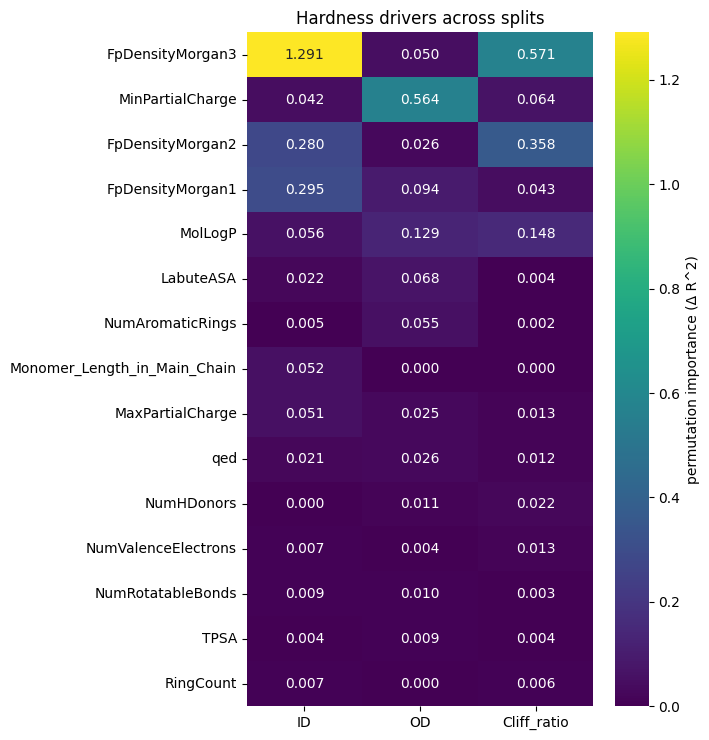

In [6]:
# Heatmap of permutation importance across splits
imp_table = {}
for s, (gbr, r2, imp) in driver_results.items():
    imp_table[s] = dict(zip(imp['feature'], imp['perm_importance_mean']))
imp_df = pd.DataFrame(imp_table).fillna(0)
# select top features by max across splits
imp_df = imp_df.reindex(imp_df.max(axis=1).sort_values(ascending=False).head(15).index)
plt.figure(figsize=(7, 0.4*len(imp_df)+1.5))
sns.heatmap(imp_df, cmap='viridis', annot=True, fmt='.3f', cbar_kws={'label':'permutation importance (Δ R^2)'} )
plt.title('Hardness drivers across splits')
plt.tight_layout(); plt.show()

## 3. 2D hard region maps
Plot the test set on a key descriptor pair and highlight the hardest 10 %.

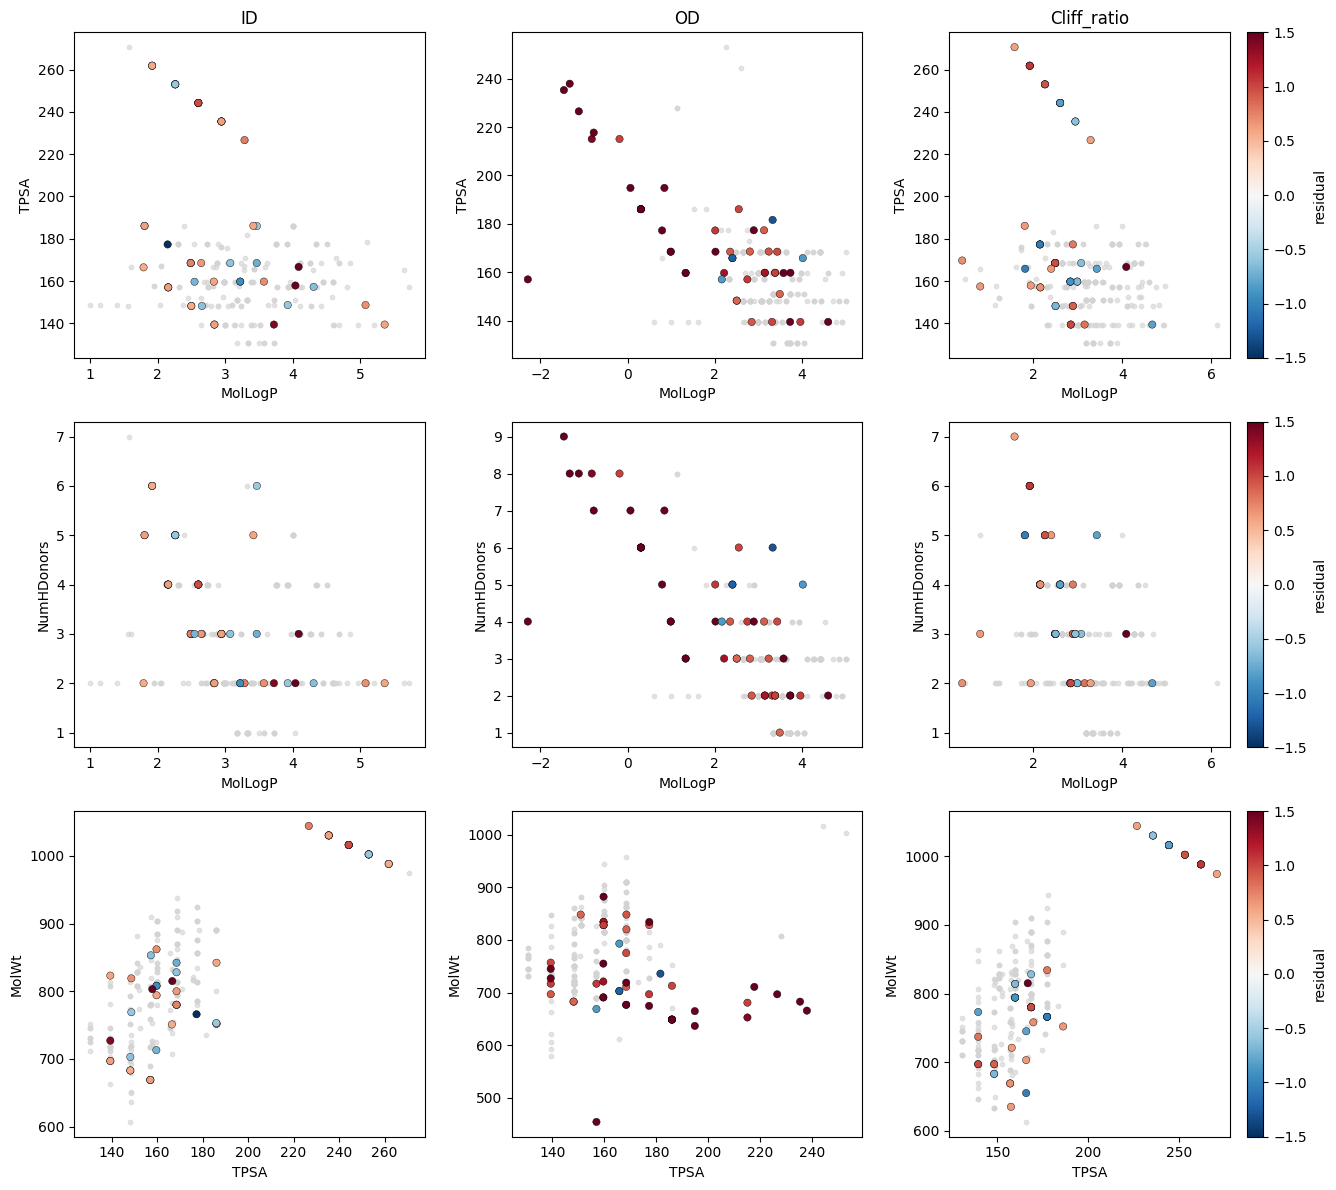

In [7]:
PAIRS = [('MolLogP','TPSA'), ('MolLogP','NumHDonors'), ('TPSA','MolWt')]
fig, axes = plt.subplots(len(PAIRS), len(frames), figsize=(4.5*len(frames), 4*len(PAIRS)), squeeze=False)
for j, (s, df) in enumerate(frames.items()):
    thr = df['abs_residual'].quantile(0.9)
    easy = df[df['abs_residual'] <  thr]
    hard = df[df['abs_residual'] >= thr]
    for i, (x, y) in enumerate(PAIRS):
        ax = axes[i, j]
        if x not in df.columns or y not in df.columns:
            ax.set_visible(False); continue
        ax.scatter(easy[x], easy[y], s=10, c='lightgray', alpha=0.6, label='rest')
        sc = ax.scatter(hard[x], hard[y], s=28, c=hard['residual'], cmap='RdBu_r', vmin=-1.5, vmax=1.5,
                        edgecolor='k', linewidth=0.3, label='hardest 10%')
        ax.set_xlabel(x); ax.set_ylabel(y)
        if i == 0: ax.set_title(s)
        if j == len(frames)-1:
            plt.colorbar(sc, ax=ax, label='residual')
plt.tight_layout(); plt.show()

## 4. Sequence-level (monomer length)

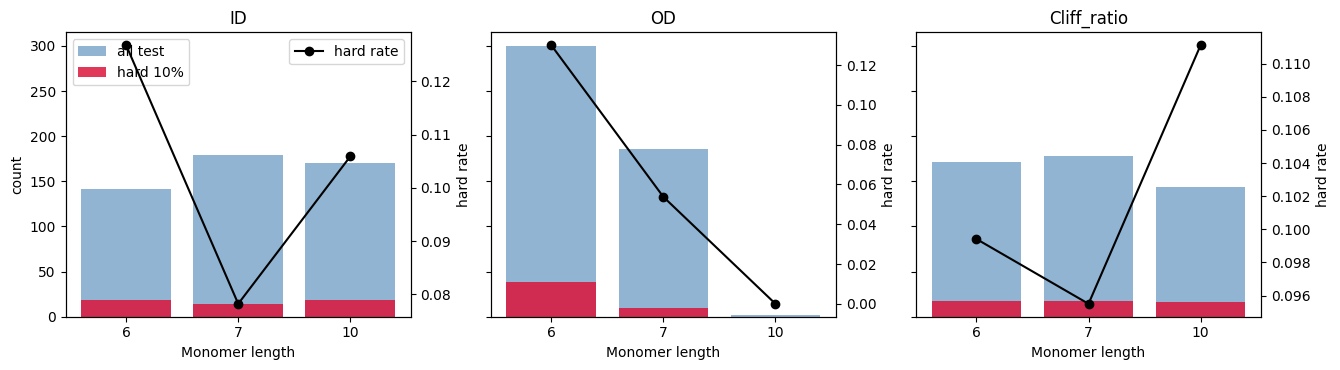

In [8]:
fig, axes = plt.subplots(1, len(frames), figsize=(4.5*len(frames), 3.8), sharey=True)
if len(frames) == 1: axes = [axes]
for ax, (s, df) in zip(axes, frames.items()):
    if 'Monomer_Length' not in df.columns:
        ax.set_visible(False); continue
    thr = df['abs_residual'].quantile(0.9)
    counts_all  = df['Monomer_Length'].value_counts().sort_index()
    counts_hard = df.loc[df['abs_residual']>=thr,'Monomer_Length'].value_counts().reindex(counts_all.index, fill_value=0)
    rate = counts_hard / counts_all
    ax2 = ax.twinx()
    ax.bar(counts_all.index.astype(str), counts_all.values, color='steelblue', alpha=0.6, label='all test')
    ax.bar(counts_hard.index.astype(str), counts_hard.values, color='crimson', alpha=0.85, label='hard 10%')
    ax2.plot(counts_all.index.astype(str), rate.values, 'k-o', linewidth=1.5, label='hard rate')
    ax2.set_ylabel('hard rate', color='k')
    ax.set_title(s); ax.set_xlabel('Monomer length')
    if ax is axes[0]:
        ax.set_ylabel('count'); ax.legend(loc='upper left')
        ax2.legend(loc='upper right')
plt.tight_layout(); plt.show()

## 5. Cross-split overlap of hard samples
How many hard-10% molecules are shared between splits? Only IDs present in both test sets are considered.

In [9]:
hard_sets = {}
for s, df in frames.items():
    thr = df['abs_residual'].quantile(0.9)
    hard_sets[s] = set(df.loc[df['abs_residual']>=thr,'CycPeptMPDB_ID'])

# overlap matrix
splits = list(hard_sets)
M = pd.DataFrame(index=splits, columns=splits, dtype=int)
for a in splits:
    for b in splits:
        M.loc[a,b] = len(hard_sets[a] & hard_sets[b])
print('|hard ∩| matrix:')
display(M)

# also intersect the test ID *populations* (not just hard) so we know the denominator
all_sets = {s: set(df['CycPeptMPDB_ID']) for s, df in frames.items()}
print('\nshared test population (pairs):')
for i,a in enumerate(splits):
    for b in splits[i+1:]:
        common = all_sets[a] & all_sets[b]
        ha = hard_sets[a] & common
        hb = hard_sets[b] & common
        both = ha & hb
        print(f'  {a}↔{b}: shared test={len(common)}, hard in {a}={len(ha)}, hard in {b}={len(hb)}, hard in both={len(both)}')

|hard ∩| matrix:


,ID,OD,Cliff_ratio
ID,50.0,2.0,3.0
OD,2.0,49.0,0.0
Cliff_ratio,3.0,0.0,50.0



shared test population (pairs):
  ID↔OD: shared test=36, hard in ID=2, hard in OD=3, hard in both=2
  ID↔Cliff_ratio: shared test=45, hard in ID=4, hard in Cliff_ratio=4, hard in both=3
  OD↔Cliff_ratio: shared test=47, hard in OD=1, hard in Cliff_ratio=1, hard in both=0


## 6. Per-setting written summary

In [10]:
def summarise(s, df, imp):
    thr = df['abs_residual'].quantile(0.9)
    hard = df[df['abs_residual']>=thr]
    bias = df['residual'].mean()
    mae  = df['abs_residual'].mean()
    # quartile bias
    q = pd.qcut(df['y_true'], 4, labels=['Q1','Q2','Q3','Q4'])
    bias_q = df.groupby(q, observed=False)['residual'].mean()
    top_feats = imp['feature'].head(5).tolist()
    # within-hard mean of top features
    deltas = []
    for f in top_feats:
        if f not in df.columns: continue
        a = pd.to_numeric(hard[f], errors='coerce')
        b = pd.to_numeric(df.loc[df['abs_residual']<thr, f], errors='coerce')
        deltas.append((f, a.mean(), b.mean(), a.mean()-b.mean()))
    direction = ('over-prediction (model says more permeable)' if bias>0 else 'under-prediction (model says less permeable)') if abs(bias)>0.1 else 'no strong global bias'
    text = []
    text.append(f'### {s}')
    text.append(f'- N={len(df)}, MAE={mae:.3f}, bias={bias:+.3f} → {direction}.')
    text.append(f'- |residual| by y_true quartile: ' + ', '.join(f'{q}={v:.2f}' for q, v in df.groupby(q, observed=False)["abs_residual"].mean().items()))
    text.append(f'- signed residual by quartile: ' + ', '.join(f'{q}={v:+.2f}' for q,v in bias_q.items()))
    text.append(f'- top hardness drivers (permutation): {", ".join(top_feats)}')
    if deltas:
        text.append(f'- hard-10% means (vs rest):')
        for f, a, b, d in deltas:
            text.append(f'  • {f}: {a:.3f} (hard) vs {b:.3f} (rest), Δ={d:+.3f}')
    return '\n'.join(text)

from IPython.display import Markdown
for s, df in frames.items():
    _, _, imp = driver_results[s]
    display(Markdown(summarise(s, df, imp)))

### ID
- N=491, MAE=0.273, bias=-0.038 → no strong global bias.
- |residual| by y_true quartile: Q1=0.36, Q2=0.23, Q3=0.21, Q4=0.29
- signed residual by quartile: Q1=+0.22, Q2=-0.01, Q3=-0.11, Q4=-0.25
- top hardness drivers (permutation): FpDensityMorgan3, FpDensityMorgan1, FpDensityMorgan2, MolLogP, Monomer_Length_in_Main_Chain
- hard-10% means (vs rest):
  • FpDensityMorgan3: 1.707 (hard) vs 1.710 (rest), Δ=-0.003
  • FpDensityMorgan1: 0.632 (hard) vs 0.631 (rest), Δ=+0.001
  • FpDensityMorgan2: 1.148 (hard) vs 1.151 (rest), Δ=-0.002
  • MolLogP: 2.841 (hard) vs 2.982 (rest), Δ=-0.141
  • Monomer_Length_in_Main_Chain: 6.800 (hard) vs 6.812 (rest), Δ=-0.012

### OD
- N=488, MAE=0.377, bias=+0.193 → over-prediction (model says more permeable).
- |residual| by y_true quartile: Q1=0.74, Q2=0.30, Q3=0.20, Q4=0.27
- signed residual by quartile: Q1=+0.73, Q2=+0.22, Q3=-0.00, Q4=-0.18
- top hardness drivers (permutation): MinPartialCharge, MolLogP, FpDensityMorgan1, LabuteASA, NumAromaticRings
- hard-10% means (vs rest):
  • MinPartialCharge: -0.429 (hard) vs -0.351 (rest), Δ=-0.077
  • MolLogP: 1.853 (hard) vs 3.121 (rest), Δ=-1.268
  • FpDensityMorgan1: 0.629 (hard) vs 0.620 (rest), Δ=+0.009
  • LabuteASA: 306.581 (hard) vs 330.078 (rest), Δ=-23.497
  • NumAromaticRings: 1.918 (hard) vs 2.210 (rest), Δ=-0.291

### Cliff_ratio
- N=493, MAE=0.284, bias=-0.018 → no strong global bias.
- |residual| by y_true quartile: Q1=0.39, Q2=0.27, Q3=0.19, Q4=0.28
- signed residual by quartile: Q1=+0.24, Q2=-0.01, Q3=-0.07, Q4=-0.24
- top hardness drivers (permutation): FpDensityMorgan3, FpDensityMorgan2, MolLogP, MinPartialCharge, FpDensityMorgan1
- hard-10% means (vs rest):
  • FpDensityMorgan3: 1.707 (hard) vs 1.721 (rest), Δ=-0.014
  • FpDensityMorgan2: 1.149 (hard) vs 1.158 (rest), Δ=-0.009
  • MolLogP: 2.508 (hard) vs 2.922 (rest), Δ=-0.414
  • MinPartialCharge: -0.385 (hard) vs -0.382 (rest), Δ=-0.003
  • FpDensityMorgan1: 0.634 (hard) vs 0.635 (rest), Δ=-0.001

In [11]:
# Save artefacts: union hard sample CSV with all descriptors + per-split summary text
OUT_CSV  = ROOT / 'eda' / 'hard_samples_deep_all.csv'
OUT_TXT  = ROOT / 'eda' / 'hard_samples_summary.md'
parts = []
for s, df in frames.items():
    thr = df['abs_residual'].quantile(0.9)
    h = df[df['abs_residual']>=thr].copy()
    h['split'] = s
    parts.append(h)
pd.concat(parts, ignore_index=True).to_csv(OUT_CSV, index=False)
with open(OUT_TXT, 'w') as f:
    f.write('# Per-setting hard sample summary\n\n')
    for s, df in frames.items():
        _, _, imp = driver_results[s]
        f.write(summarise(s, df, imp))
        f.write('\n\n')
print(f'wrote {OUT_CSV} and {OUT_TXT}')

wrote /ssd0/sohyun/cyclic_peptide/cyclic_peptide_permeability/eda/hard_samples_deep_all.csv and /ssd0/sohyun/cyclic_peptide/cyclic_peptide_permeability/eda/hard_samples_summary.md
